In [1]:
%cd ../
%load_ext autoreload
%autoreload 2

/Users/matthaei/Documents/code/python/bachelor-project


In [2]:
MIGRATE_DATABASE = False

In [4]:
from src.weather_stations.weather_station_service import WeatherStationService
from src.measurements.measurement_service import MeasurementService
from src.calculation.calculation_service import CalculationService
from src.wind_turbines.wind_turbines_service import WindTurbinesService
from src.database.database_service import DatabaseService
from src.aggregation.aggregation_service import AggregationService
from omegaconf import DictConfig, OmegaConf
from hydra import compose, initialize_config_dir
import os

In [6]:
# Initialize Hydra configuration
config_dir = os.path.abspath("./conf")

# Initialize Hydra with the config directory
with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(config_name="config")

In [7]:
database_service = DatabaseService(cfg)

if MIGRATE_DATABASE:
    database_service.create_tables()

## Load all measurements

In [8]:
aggregation_service = AggregationService(cfg, database_service)

In [18]:
aggregations_df = aggregation_service.get_aggregated_data_for_last_24_hours()

In [19]:
aggregations_df

,avg_extrapolated_hub_height_wind_speed,has_prediction,num_rows,record_date,sum_pred_power_production
0,3.286975,0,4798,2025-09-16 19:40:00,140275.0
1,3.286975,0,4798,2025-09-16 19:50:00,140275.0
2,3.286975,0,4798,2025-09-16 20:00:00,140275.0
3,3.286975,0,4798,2025-09-16 20:10:00,140275.0
4,3.286975,0,4798,2025-09-16 20:20:00,140275.0
...,...,...,...,...,...
139,0.925377,1,4798,2025-09-17 18:50:00,0.0
140,0.926935,1,4798,2025-09-17 19:00:00,0.0
141,0.922684,1,4798,2025-09-17 19:10:00,0.0
142,0.922551,1,4798,2025-09-17 19:20:00,0.0


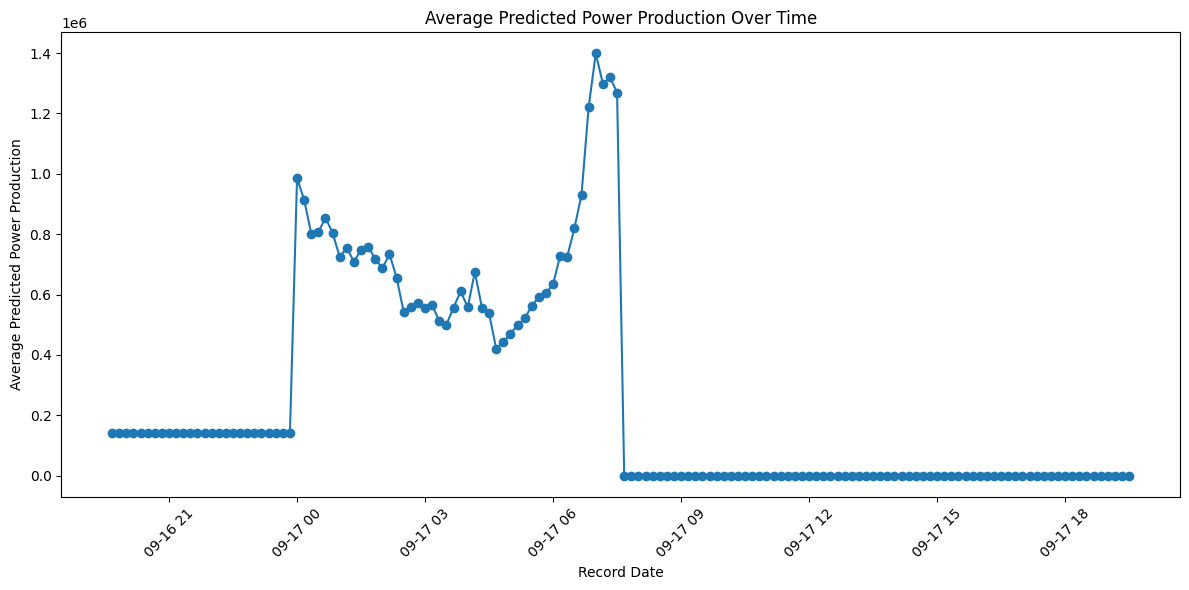

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(aggregations_df['record_date'], aggregations_df['sum_pred_power_production'], marker='o', linestyle='-')
plt.xlabel('Record Date')
plt.ylabel('Average Predicted Power Production')
plt.title('Average Predicted Power Production Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Load for one wind turbine

In [30]:
one_turbine_df = aggregation_service.get_data_for_one_turbine_for_last_24_hours("SEE978883707494")

In [31]:
one_turbine_df

,extrapolated_hub_height_wind_speed,is_prediction,pred_power_production,record_date
0,2.372241,False,9.0,2025-09-16 19:40:00
1,2.372241,False,9.0,2025-09-16 19:50:00
2,2.372241,False,9.0,2025-09-16 20:00:00
3,2.372241,False,9.0,2025-09-16 20:10:00
4,2.372241,False,9.0,2025-09-16 20:20:00
...,...,...,...,...
139,0.938501,True,0.0,2025-09-17 18:50:00
140,0.940062,True,0.0,2025-09-17 19:00:00
141,0.935857,True,0.0,2025-09-17 19:10:00
142,0.935724,True,0.0,2025-09-17 19:20:00


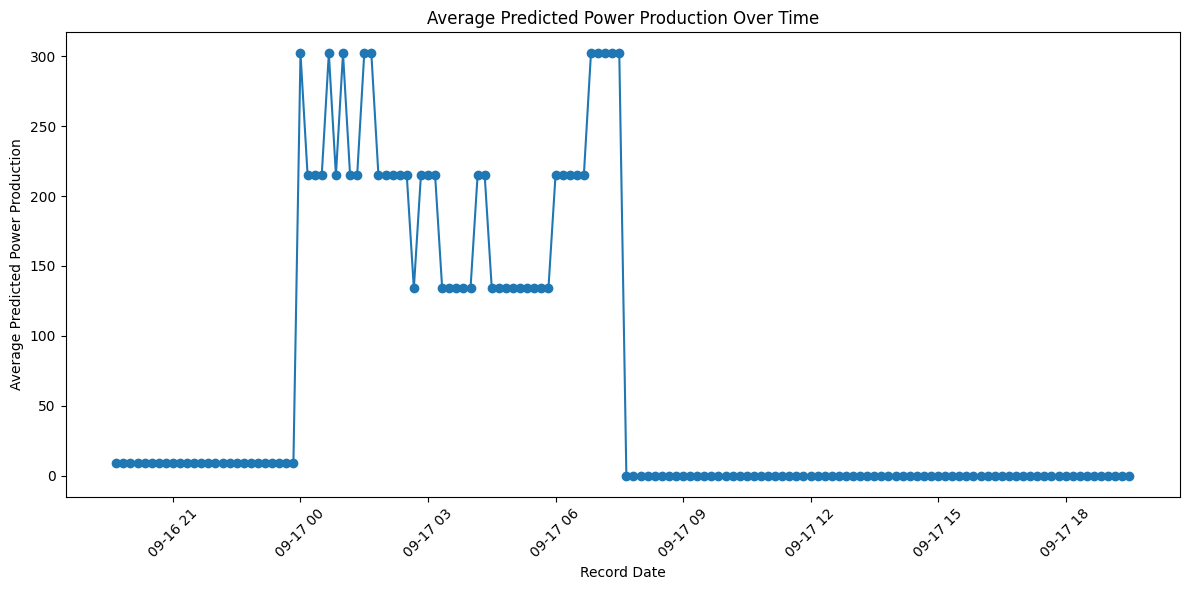

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(one_turbine_df['record_date'], one_turbine_df['pred_power_production'], marker='o', linestyle='-')
plt.xlabel('Record Date')
plt.ylabel('Average Predicted Power Production')
plt.title('Average Predicted Power Production Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
